<a href="https://colab.research.google.com/github/Fei-Q/dsst389/blob/main/nb/notebook15a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Notebook15a

### Setup

Run all of the following before starting the notebook.

In [1]:
! wget -q -nc https://raw.githubusercontent.com/taylor-arnold/fds-py-nb/refs/heads/main/funs.py

In [2]:
import numpy as np
import polars as pl

from funs import *
from plotnine import *
from polars import col as c

import torch
import torch.nn as nn
import torch.optim as optim

theme_set(theme_minimal())
pl.Config(tbl_rows=25)

ub = "https://raw.githubusercontent.com/taylor-arnold/fds-py-nb/refs/heads/main/"

In [3]:
agnews = pl.read_parquet(ub + "data/agnews_pca.parquet")
amazon = pl.read_parquet(ub + "data/amazon_pca.parquet")
inet = pl.read_parquet(ub + "data/imagenette_1000.parquet")
woof = pl.read_parquet(ub + "data/imagewoof_1000.parquet")

### AG News

1.  We will start by plotting the UMAP embedding of the E5 embedding vectors from the AG News dataset. How much structure is captured already by the embedding vectors?

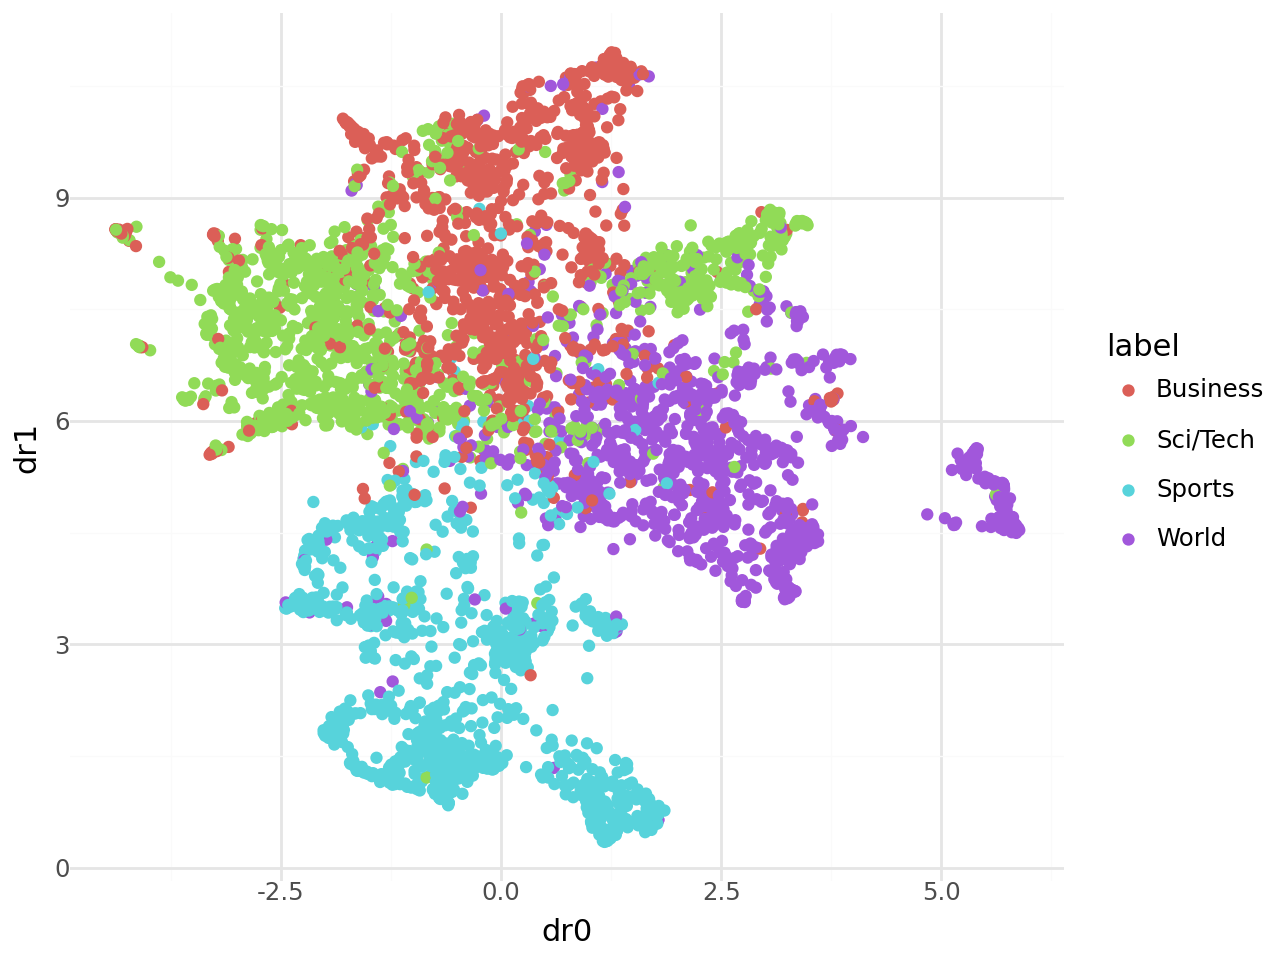

In [4]:
(
    agnews
    .sample(n=5000, seed=42)
    .pipe(
        DSSklearn.umap,
        features=[c.e5]
    )
    .predict(full=True)
    .pipe(ggplot, aes("dr0", "dr1"))
    + geom_point(aes(color="label"))
)

2. Now let's fit a shallow logistic regression model on the data.

In [5]:
model = (
    agnews
    .pipe(
        DSSklearn.logistic_regression_cv,
        target=c.label,
        features=[c.e5],
        stratify=c.label,
        solver="saga"
    )
)

3. And look at its score and confusion matrix. Notice that it does as well, but not noticably better, than our previous model. It's likely the miscategorized examples are really edge cases between the two categories.

In [6]:
model.score()

{'train': 0.9093708016121809, 'test': 0.9064002089864159}

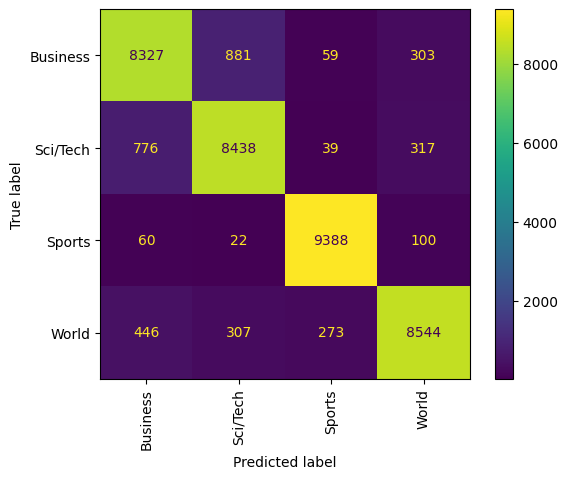

In [7]:
model.confusion_matrix()

### Amazon Product Reviews

4. Let's move on to another dataset, this time product categories from Amazon reviews. We'll mostly follow the same steps again, starting with a plot:

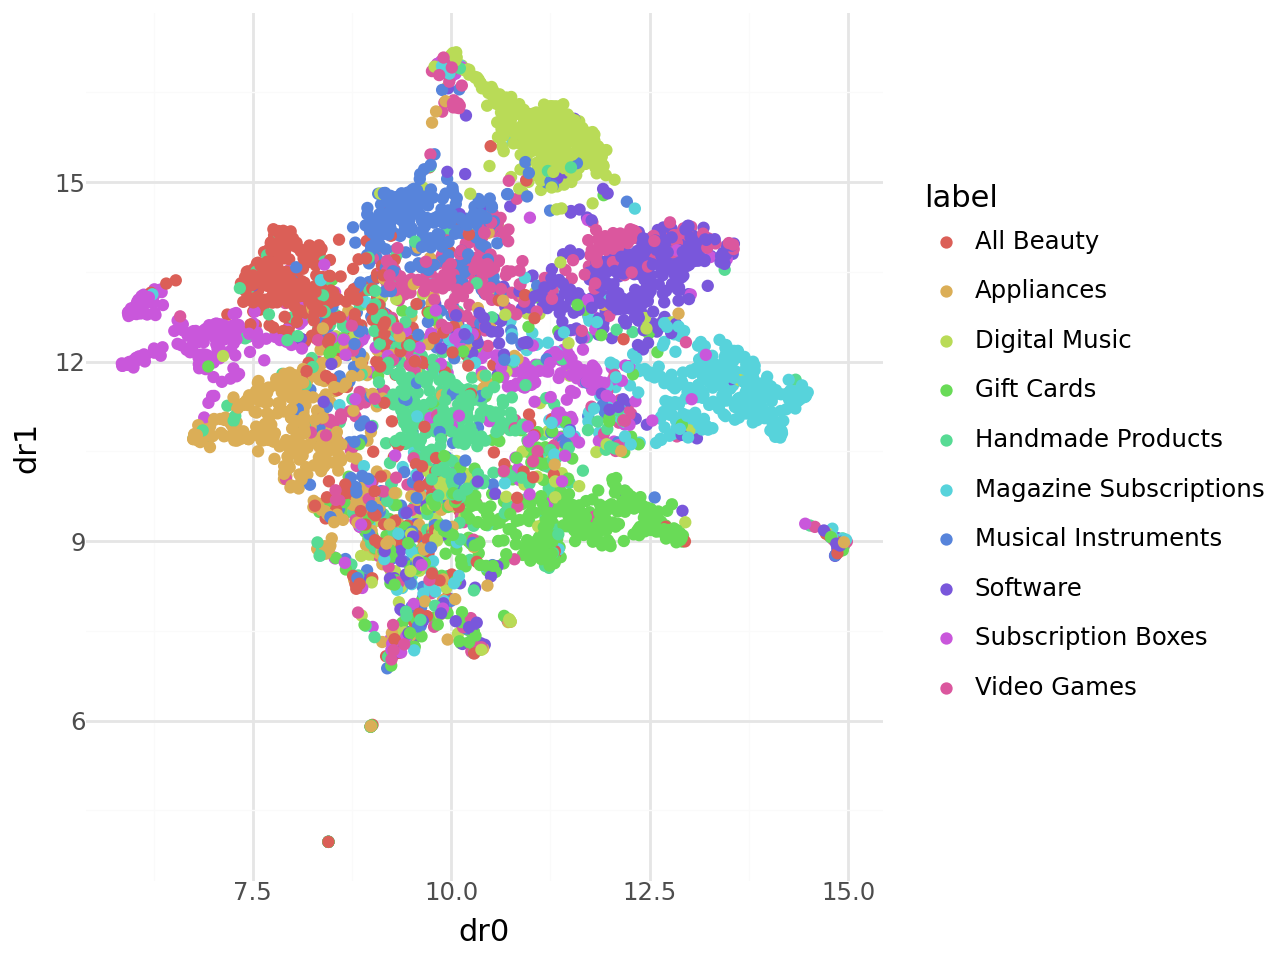

In [8]:
(
    amazon
    .sample(n=5000, seed=42)
    .pipe(
        DSSklearn.umap,
        features=[c.e5]
    )
    .predict(full=True)
    .pipe(ggplot, aes("dr0", "dr1"))
    + geom_point(aes(color="label"))
)

5. Next, build a model.

In [9]:
model = (
    amazon
    .pipe(
        DSSklearn.logistic_regression_cv,
        target=c.label,
        features=[c.e5],
        stratify=c.label,
        solver="saga"
    )
)

6. And then see how well it performs. This is clearly a harder task from the classification rates. Was that also clear from the plot above?

In [10]:
model.score()

{'train': 0.784, 'test': 0.7473333333333333}

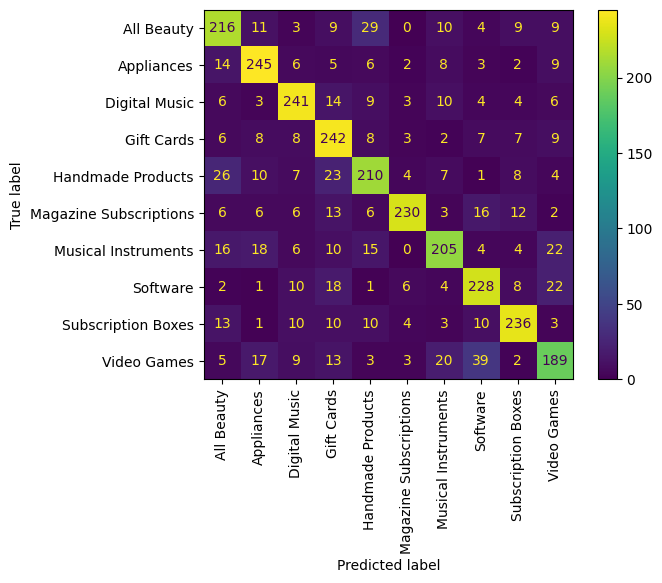

In [11]:
model.confusion_matrix()

### Imagenette

7. Let's move on to an image dataset. Here we have a subset of the Imagenet challenge, consisting of only 10 fairly distinct categories. Let's build a similar plot as with the text data using the `vit` embeddings. How does this compare to the embedding of the text. Why do you think this is?

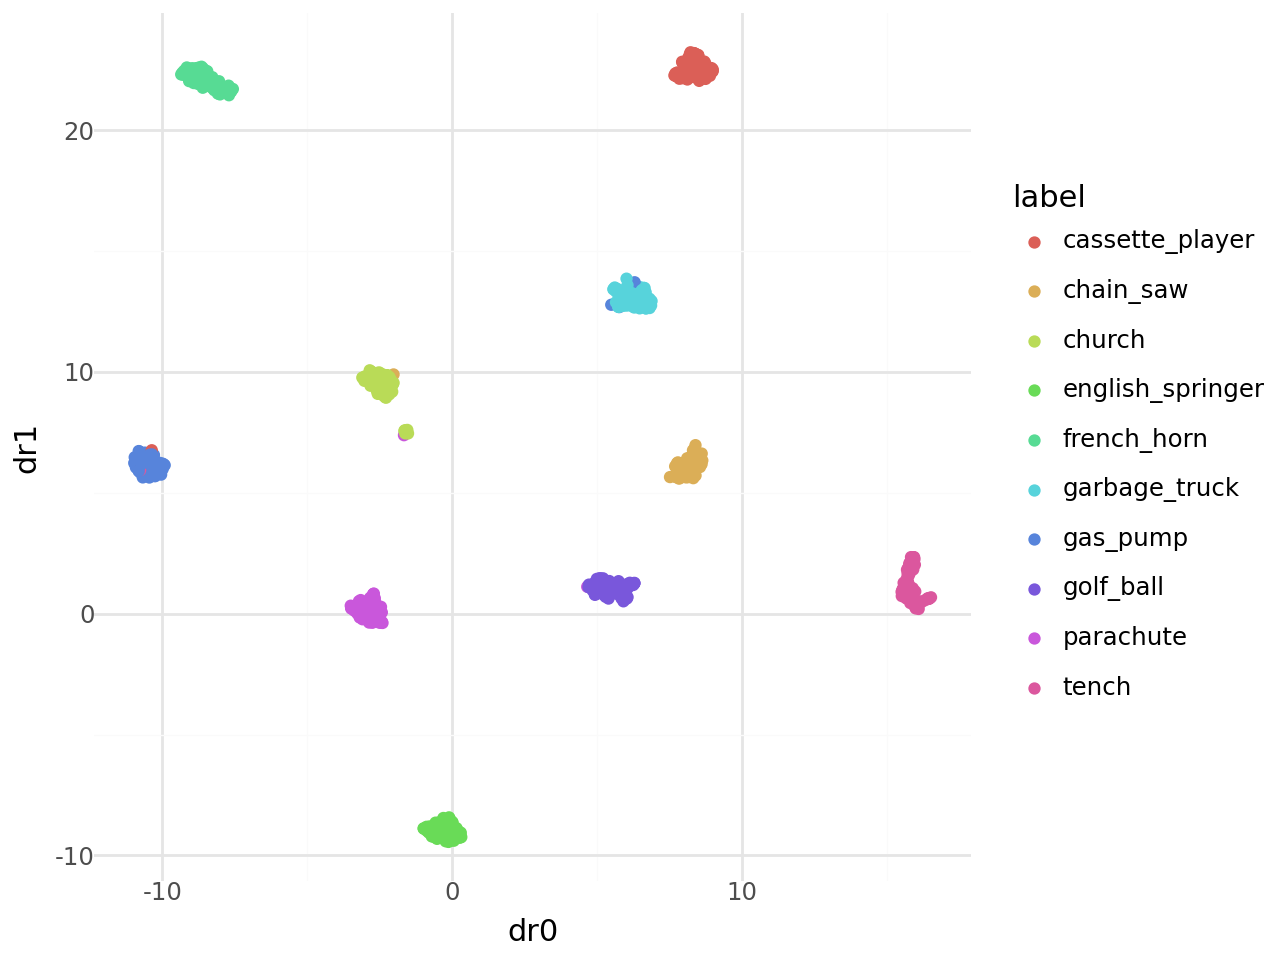

In [12]:

(
    inet
    .pipe(
        DSSklearn.umap,
        features=[c.vit]
    )
    .predict(full=True)
    .pipe(ggplot, aes("dr0", "dr1"))
    + geom_point(aes(color="label"))
)

9. Now, fit a model on the image data to predict the category.

In [13]:
model = (
    inet
    .pipe(
        DSSklearn.logistic_regression_cv,
        target=c.label,
        features=[c.vit],
        stratify=c.label,
        solver="saga",
        max_iter=1000,
        cv=3
    )
)

10. Check the score and confusion matrix. Does this surprise you at all?

In [14]:
model.score()

{'train': 1.0, 'test': 0.9933333333333333}

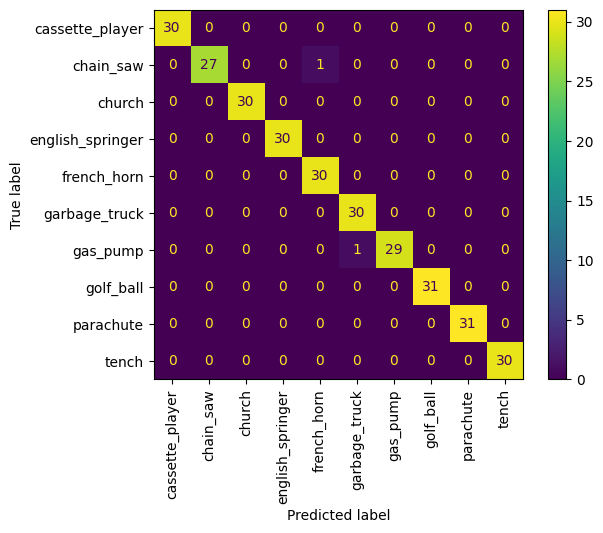

In [15]:
model.confusion_matrix()

11. Alright, so we can do classification very well with the training data. What about *without* training data? Run the following the get the embedding of the phrase "a photo of a French horn".

In [16]:
siglip = SigLIPEmbedder()

embed = (
    pl.DataFrame({"text": ["a photo of a French horn"]})
    .with_columns(
        siglip_txt = c.text.map_elements(
            siglip.embed_text,
            return_dtype=pl.List(pl.Float32)
        )
    )
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/322 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

12. And visualize how related the embeddings are to the labels. How well do you think the unsupervised model will do at prediction with no training data?

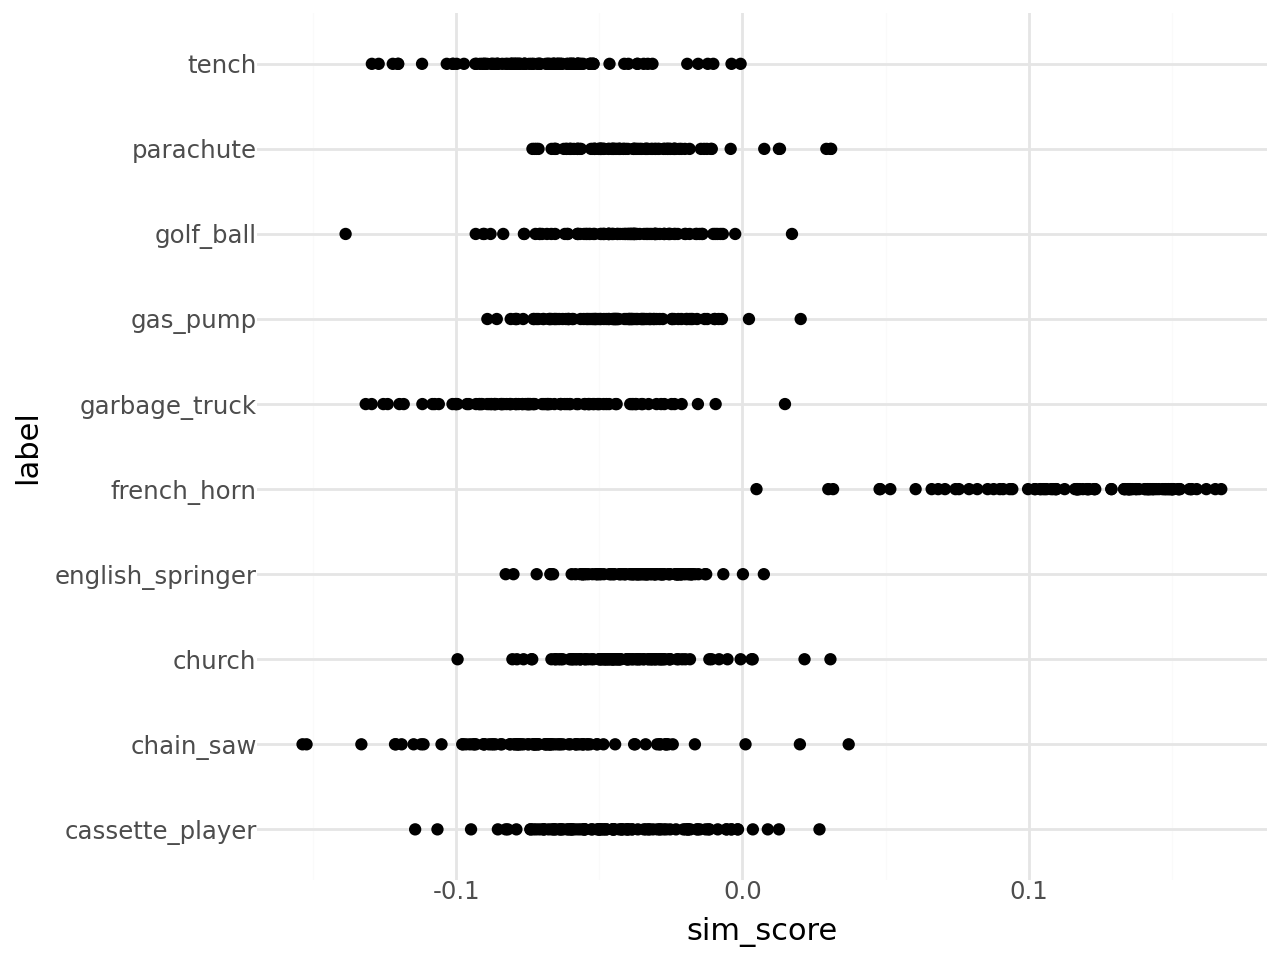

In [17]:
(
    inet
    .join(embed, how="cross")
    .with_columns(
        sim_score = dot_product(c.siglip, c.siglip_txt)
    )
    .pipe(ggplot, aes("sim_score", "label"))
    + geom_point()
)

13. Now, we will embed the name of each label and store all of the embeddings.

In [18]:
embed = (
    inet
    .select(text = c.label.unique())
    .with_columns(
        siglip_txt = c.text.map_elements(
            siglip.embed_text, return_dtype=pl.List(pl.Float32)
        )
    )
)

14. And then compute all of the pairs of scores, recording how often the top score corresponds to the correct label.

In [19]:
(
    inet
    .join(embed, how="cross")
    .with_columns(
        sim_score = dot_product(c.siglip, c.siglip_txt)
    )
    .sort(c.sim_score, descending=True)
    .group_by(c.filepath)
    .head(1)
    .select(class_rate = (c.label == c.text).mean())
)

class_rate
f64
0.994


### Image Woof

15. We will finish by doing the same thing with a dataset that is considered more difficult. It's another subset of Imagenet, called called Image Woof, with 10 select labels from the set. However, this time we have ten dog breeds, which all look much more similar that the Imagenette categories. So, in theory, this will be harder. Let's see a plot.

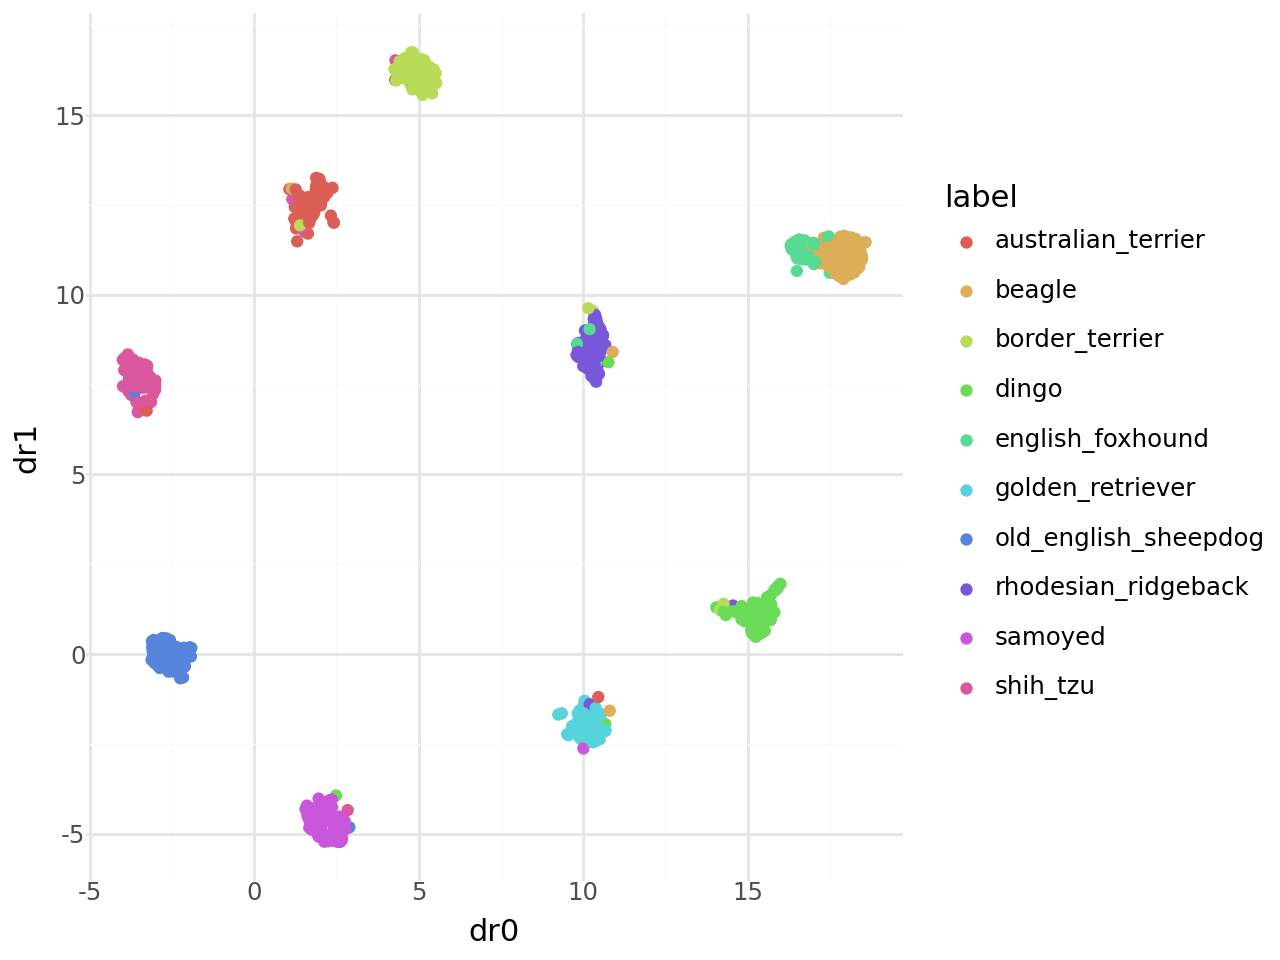

In [20]:
(
    woof
    .pipe(
        DSSklearn.umap,
        features=[c.vit]
    )
    .predict(full=True)
    .pipe(ggplot, aes("dr0", "dr1"))
    + geom_point(aes(color="label"))
)

16. Well, let's make a model, which should be fairly good again given the plot.

In [21]:
model = (
    woof
    .pipe(
        DSSklearn.logistic_regression_cv,
        target=c.label,
        features=[c.vit],
        stratify=c.label,
        solver="saga",
        max_iter=1000,
        cv=3
    )
)

17. And verify that it does work well:

In [22]:
model.score()

{'train': 0.9928571428571429, 'test': 0.9666666666666667}

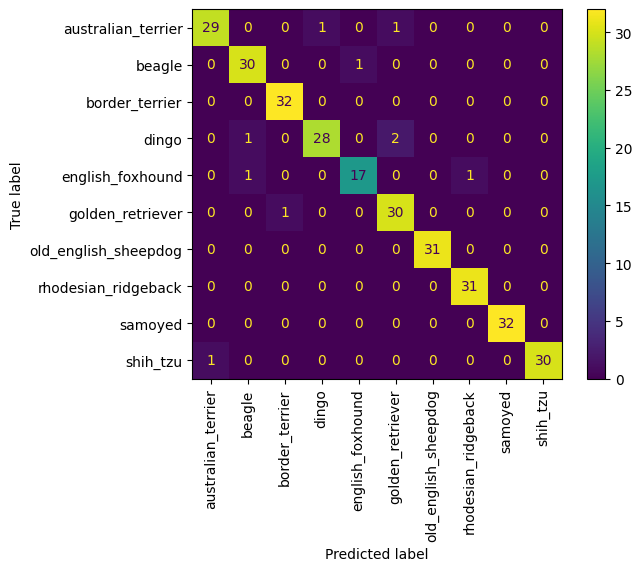

In [23]:
model.confusion_matrix()

18. Now, as before, let's try a zero-shot model. We'll start with a visualization of the phrase "a golden retriever".

In [24]:
siglip = SigLIPEmbedder()

embed = (
    pl.DataFrame({"text": ["a golden retriever"]})
    .with_columns(
        siglip_txt = c.text.map_elements(
            siglip.embed_text,
            return_dtype=pl.List(pl.Float32)
        )
    )
)

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

19. Looking at the visualization, how does this this compare to the example from before?

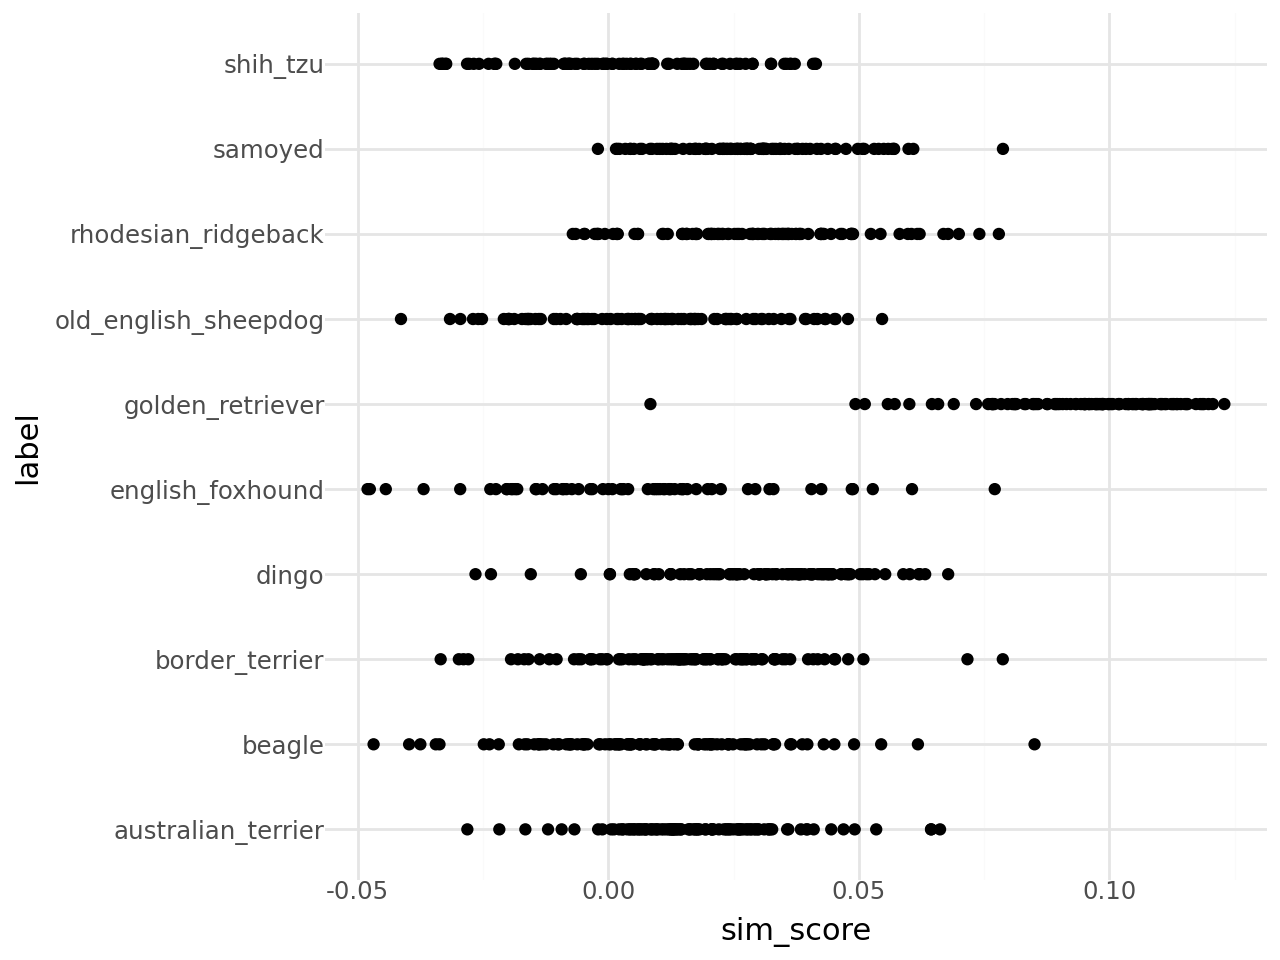

In [25]:
(
    woof
    .join(embed, how="cross")
    .with_columns(
        sim_score = dot_product(c.siglip, c.siglip_txt)
    )
    .pipe(ggplot, aes("sim_score", "label"))
    + geom_point()
)

20. As before, let's try to get an embedding of each text and build a full zero-shot model

In [26]:
embed = (
    woof
    .select(text = c.label.unique())
    .with_columns(
        siglip_txt = c.text.map_elements(
            siglip.embed_text, return_dtype=pl.List(pl.Float32)
        )
    )
)

21. Now, evaluate how well the model works:

In [27]:
(
    woof
    .join(embed, how="cross")
    .with_columns(
        sim_score = dot_product(c.siglip, c.siglip_txt)
    )
    .sort(c.sim_score, descending=True)
    .group_by(c.filepath)
    .head(1)
    .select(class_rate = (c.label == c.text).mean())
)

class_rate
f64
0.891


22. You should see that the model does well, but isn't perfect. This final visualization shows that the SigLIP space is not a perfect model of the categories of dog breeds. The reason is that it isn't trained to categorize that way; it encodes a lot of other information that degrades the performance for simple category look-ups.

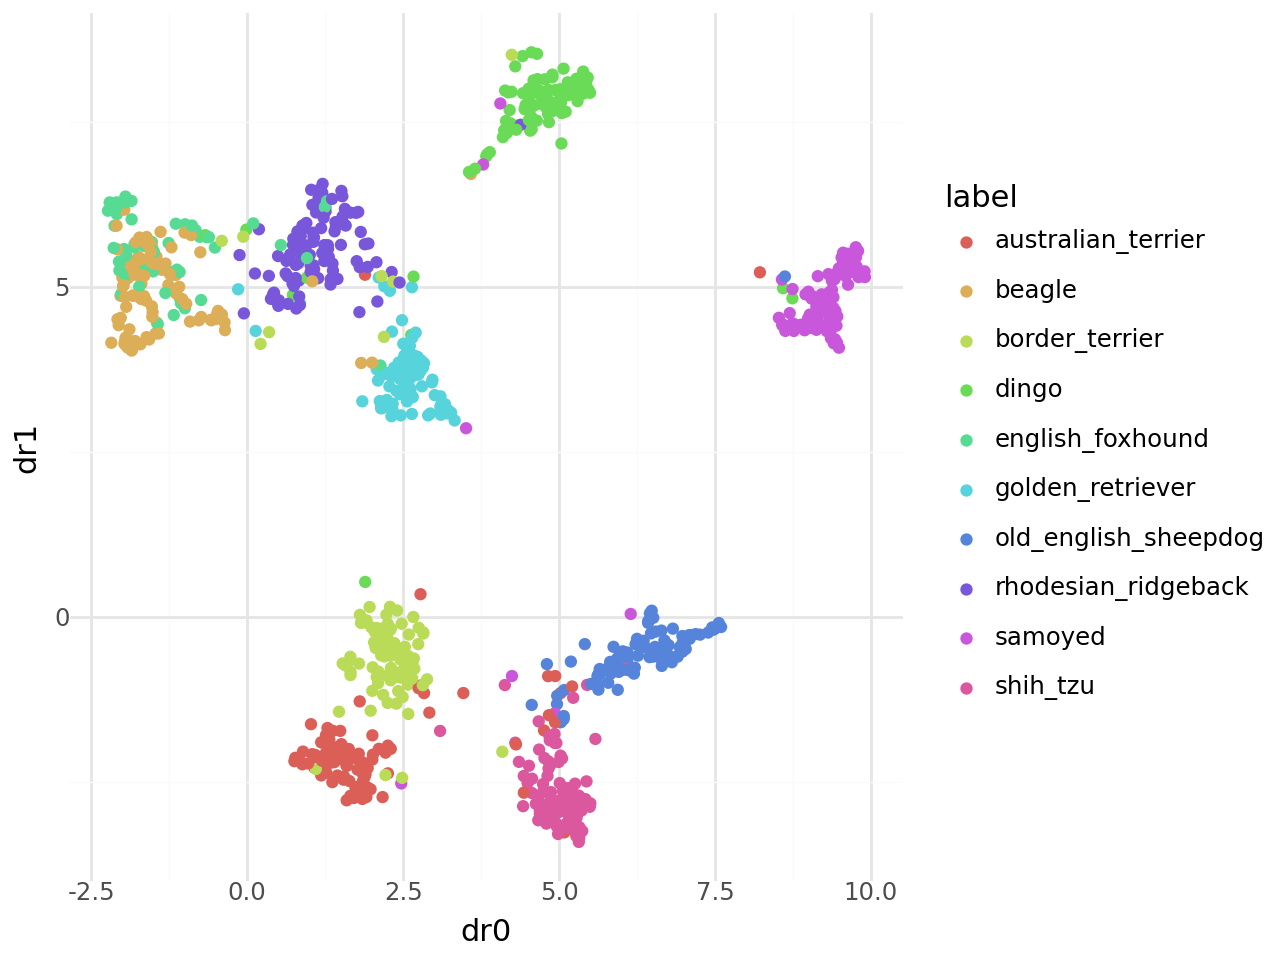

In [28]:
(
    woof
    .pipe(
        DSSklearn.umap,
        features=[c.siglip]
    )
    .predict(full=True)
    .pipe(ggplot, aes("dr0", "dr1"))
    + geom_point(aes(color="label"))
)